In [1]:
from variables import pd, df, train_df, test_df, X_train, X_test, y_train, y_test, vocab, counts, nums, vectorizer

In [3]:
# numbers appearing on dataset
nums = [w for w in vocab if w.isdigit()]
print(counts.loc[nums])

     human  ai
10      15   0
100      4   1
15       8   0
20       6   0
24       5   2
30       7   0
40       4   1


In [4]:
# top 5 words is used by AI and tops 5 words used by human
print(len(vocab))
print(counts.sort_values("ai", ascending=False).head(5))
print(counts.sort_values("human", ascending=False).head(5))

1304
     human    ai
the   2395  3935
and   1256  1873
was    975  1621
to     922  1003
of     460   776
     human    ai
the   2395  3935
and   1256  1873
was    975  1621
to     922  1003
in     595   654


In [5]:
# Splitting train set
import pandas as pd
from variables import df, train_df, test_df

# 1. sizes
print(len(train_df), len(test_df))

# 2. groups in train and test
print(pd.crosstab(train_df["source"], train_df["Sentiment"]))
print(pd.crosstab(test_df["source"], test_df["Sentiment"]))

# 3. no review in both sets, and none lost
print(len(set(train_df.index) & set(test_df.index)))
print(len(train_df) + len(test_df) == len(df))

1500 500
Sentiment  NEG  POS
source             
0          375  375
1          375  375
Sentiment  NEG  POS
source             
0          125  125
1          125  125
0
True


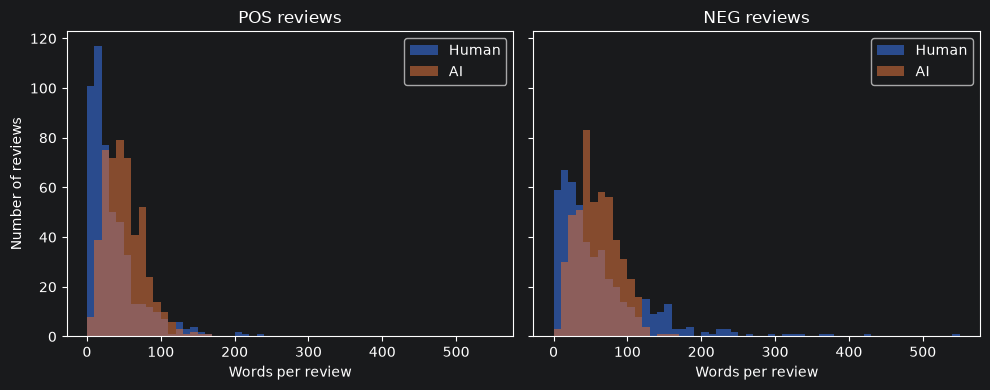

In [6]:
#Positive Review and Negative Reviews comparison
import matplotlib.pyplot as plt
from variables import df

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
bins = range(0, df["n_words"].max() + 10, 10)

for ax, sentiment in zip(axes, ["POS", "NEG"]):
    subset = df[df["Sentiment"] == sentiment]
    ax.hist(subset.loc[subset["source"] == 0, "n_words"], bins=bins, alpha=0.6, label="Human")
    ax.hist(subset.loc[subset["source"] == 1, "n_words"], bins=bins, alpha=0.6, label="AI")
    ax.set_title(f"{sentiment} reviews")
    ax.set_xlabel("Words per review")
    ax.legend()

axes[0].set_ylabel("Number of reviews")
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer



train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')

# empty texts are read back from csv as NaN
train_df['text'] = train_df['text'].fillna('')
test_df['text'] = test_df['text'].fillna('')

y_train = train_df['source']
y_test = test_df['source']

# bag-of-words: lowercase, words in fewer than 5 training reviews dropped
vec = CountVectorizer(lowercase=True, min_df=5, token_pattern=r'(?u)\b[^\W\d_]{2,}\b')

# vocabulary learned on the training set only
X_train = vec.fit_transform(train_df['text'])

# test set uses the training vocabulary, no refitting
X_test = vec.transform(test_df['text'])

In [8]:
#Tinkering: Separating the test set into 1200 training and 300 testng reviews
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=0)

In [9]:
from sklearn.naive_bayes import MultinomialNB
from sklearn import tree

# Naive Bayes
NB = MultinomialNB()
NB.fit(X_tr, y_tr)

#Logistic regression

#Single tree

ST = tree.DecisionTreeClassifier()
ST = ST.fit(X_tr, y_tr)

#Random forests

#Gradient boosting